This code introduces the structure for generating the synthetic dataset, the first introduced features, and their relation inside the data.
The first draft itself contains the data features dependencies on each other which helps to identify how and where the ML rules break.

In [1]:
import numpy as np
import pandas as pd

In [11]:
def generate_archery_dataset(num_shots=100):
    np.random.seed(42)

    # instead of hardcoding the constants, ill be using the hyperparameters naming:
    # alpha for rate of fatigue accumulation per unit shot,
    # beta for impact of increasing heart rate on physical stress,
    # and gamma for efficiency of recovery time on draining fatigue

    alpha = 0.025 #fatigue_level
    beta = 0.005 #heart_rate_change
    gamma = 0.0004 #recovery_time_before_shot

    # latent state baseline/ initialization at t=0
    fatigue_level = 0.1  #scale 0-1
    baseline_heart_rate = 70.0 
    
    dataset=[]

    for shot in range(1, num_shots + 1):

        #A. temporal accumulation(violated identity and independent distibution)

        #fatigue grows with shot
        # as more shots are taken the fatigue increases, not linearly but with the exponent of 0.1
        shot_load = shot ** 0.15
    
        #slight offset by random recovery time(30 to 90 seconds) between shot
        recovery_time_before_shot = np.random.uniform(30,90)

        #simulating physiological response(BPM over baseline)
        #heart rate drifts higher as fatigue builds up
        heart_rate_change = np.random.uniform(5,20) + (fatigue_level * 40)

        #2. the dynamic memory update
        # Current State = Past State + Exertion Gain + Stress Gain - Recovery Drain

        fatigue_gain = (alpha * shot_load) + (beta * heart_rate_change)
        
        # the longer the recovery, the more the shot fatigue subtracts
        recovery_drain = gamma * recovery_time_before_shot
        
        # fatigue should have a memory, thats why mathematically: fatigue(t+1) = fatigue(t) + fatigue_gain - recovery_time_before_shot
        fatigue_level = fatigue_level + fatigue_gain - recovery_drain

        #to keep physical system within biological limits, put fatigue level on scale of[0,1]
        fatigue_level = np.clip(fatigue_level, 0.0, 1.0)

        #B. Motor stability state
        #downstream consequences or state driving observable features. a direct consequence of the internal latent state

       # B. Motor stability state (with active biological compensation)
        base_tremor = np.random.normal(1.0, 0.05)
        
        if fatigue_level > 0.75:
            # 1. Beyond 0.75: Compensation breaks down completely.
            # Tremor begins to oscillate wildly and escalates exponentially.
            compensation_breakdown_factor = np.exp((fatigue_level - 0.75) * 5)
            tremor_level = base_tremor * compensation_breakdown_factor
            release_error = np.random.normal(0.05, 0.01) * (1.0 + fatigue_level * 5)
        else:
            # 2. Before 0.75: Active cognitive/motor compensation.
            # Even though fatigue is rising, the body holds the tremor steady!
            tremor_level = base_tremor  # Flat relationship
        release_error = np.random.normal(0.05, 0.01) * 1.1
        #physical degradation impact release error
       

        #target mapping
        arrow_deviation_from_center = (tremor_level * 2.5) + (release_error * 12.0) + np.random.normal(0,0.2)

        #save historical telemetry rows
        dataset.append({
            "shot_number": shot,
            "fatigue_level": fatigue_level,
            "recovery_time_before_shot": recovery_time_before_shot,
            "heart_rate_changes": heart_rate_change,
            "tremor_level": tremor_level,
            "arrow_deviation_from_center": max(0.0, arrow_deviation_from_center)
        })

    return pd.DataFrame(dataset)

df_archery = generate_archery_dataset(100)

see correlation between features using heatmap

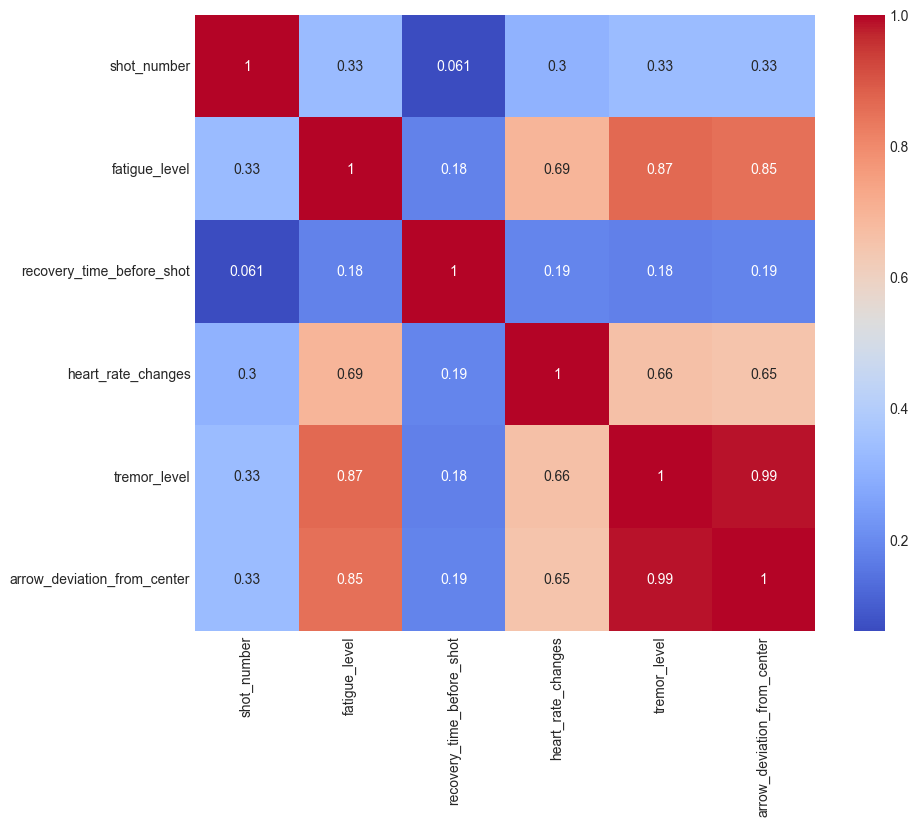

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df_archery.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

even here some of the features show complete dependency on the outcome, see how much tremor level is responsible for the resultant label.

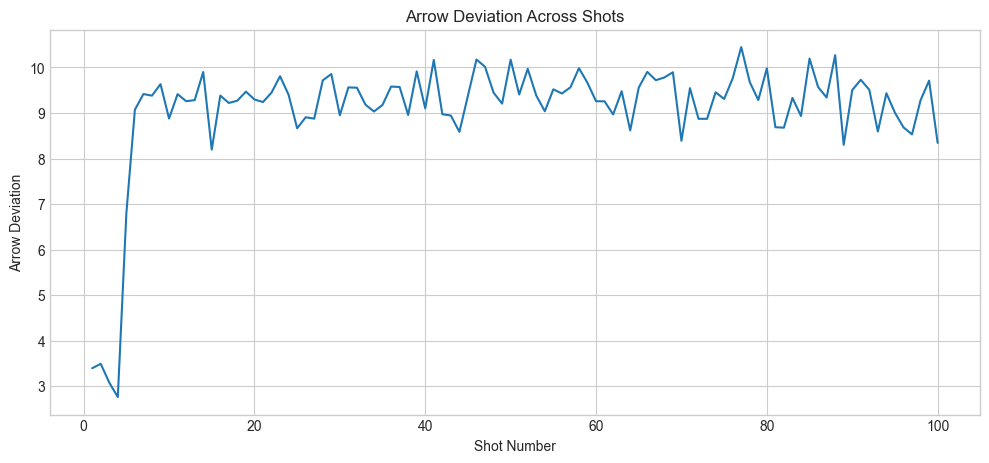

In [22]:
plt.figure(figsize=(12,5))

plt.plot(df_archery['shot_number'],
         df_archery['arrow_deviation_from_center'])

plt.xlabel('Shot Number')
plt.ylabel('Arrow Deviation')
plt.title('Arrow Deviation Across Shots')
plt.grid(True)
plt.show()

In [15]:
df_archery.head()

,shot_number,fatigue_level,recovery_time_before_shot,heart_rate_changes,tremor_level,arrow_deviation_from_center
0,1,0.220315,52.472407,23.260715,1.032384,3.395170
1,2,0.368686,33.485017,26.805227,0.988293,3.492676
2,3,0.557151,31.235070,34.296087,0.976526,3.080250
3,4,0.744415,48.254535,35.157389,0.976714,2.761637
4,5,0.933902,66.711174,36.869000,2.394187,6.793779


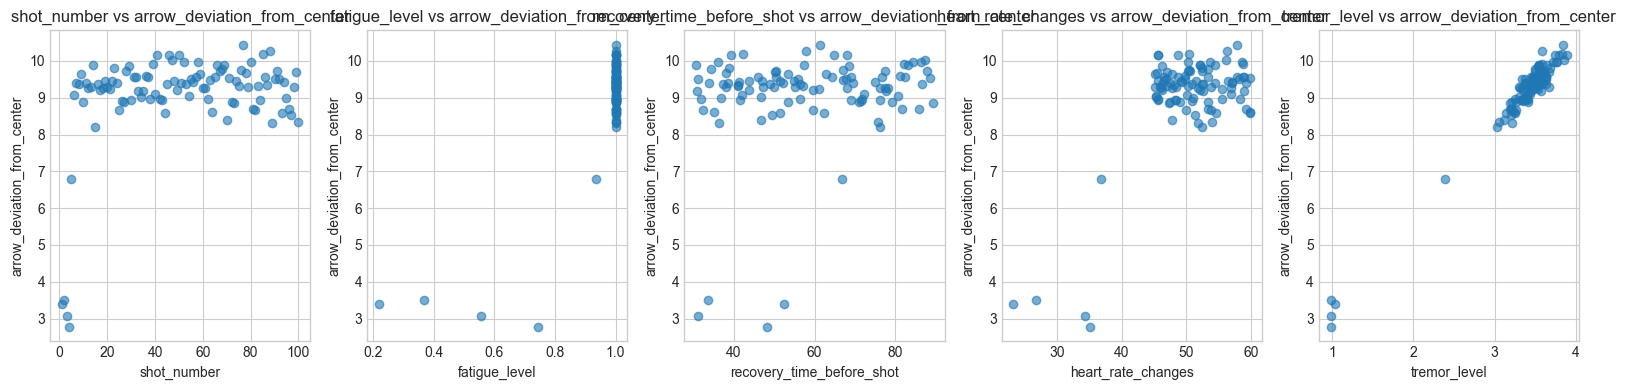

In [14]:
import matplotlib.pyplot as plt

features = [
    'shot_number',
    'fatigue_level',
    'recovery_time_before_shot',
    'heart_rate_changes',
    'tremor_level'
]

label = 'arrow_deviation_from_center'

plt.figure(figsize=(16,4))

for i, feature in enumerate(features, 1):
    plt.subplot(1,5,i)
    plt.scatter(df_archery[feature], df_archery[label], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel(label)
    plt.title(f'{feature} vs {label}')

plt.tight_layout()
plt.show()

above graph shows the data distribution between Features vs labels within their respective scales.

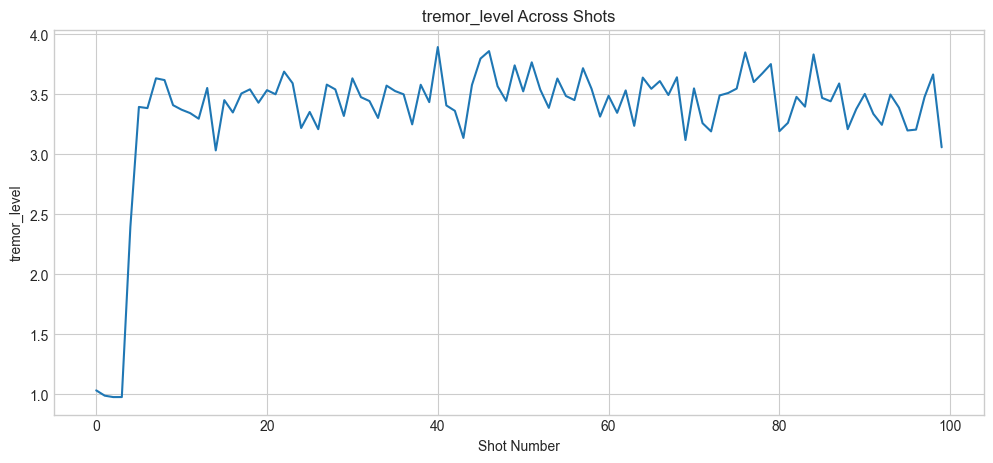

In [24]:

plt.figure(figsize=(12,5))
df_archery["tremor_level"].plot()
plt.xlabel('Shot Number')
plt.ylabel('tremor_level')
plt.title('tremor_level Across Shots')
plt.grid(True)
plt.show()

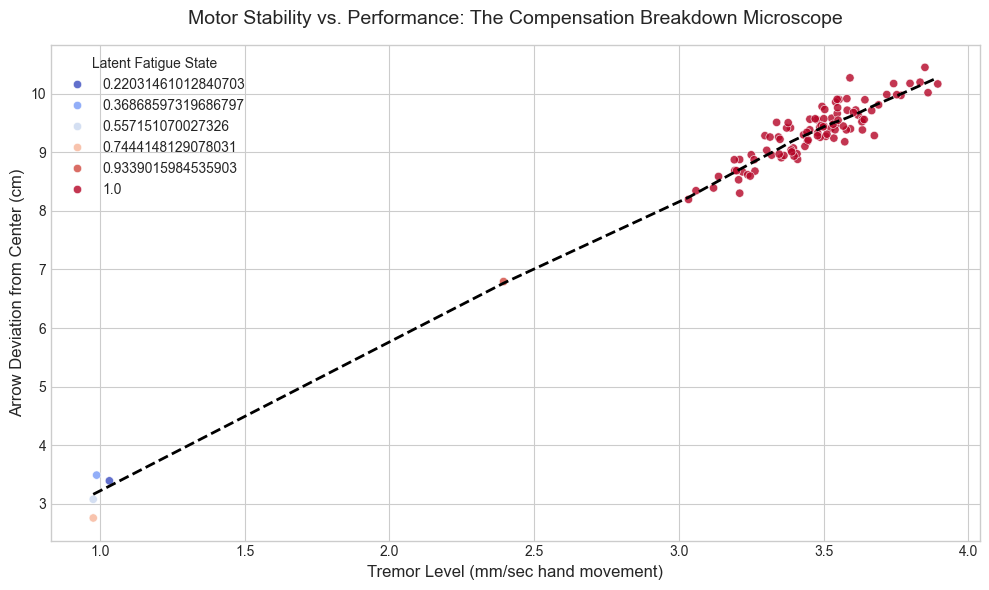

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for a clean, scientific look
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Create the scatter plot
sns.scatterplot(
    data=df_archery,
    x='tremor_level',
    y='arrow_deviation_from_center',
    hue='fatigue_level', # Color points by latent fatigue to see it creeping up
    palette='coolwarm',
    alpha=0.8,
    ax=ax
)

# 2. Add a non-linear smoothed line (LOWESS) to track the phase transition
sns.regplot(
    data=df_archery,
    x='tremor_level',
    y='arrow_deviation_from_center',
    scatter=False,
    lowess=True,
    line_kws={'color': 'black', 'linewidth': 2, 'linestyle': '--'},
    ax=ax
)

# 3. Annotate the graph to make the physics explicit
ax.set_title('Motor Stability vs. Performance: The Compensation Breakdown Microscope', fontsize=14, pad=15)
ax.set_xlabel('Tremor Level (mm/sec hand movement)', fontsize=12)
ax.set_ylabel('Arrow Deviation from Center (cm)', fontsize=12)

# Customize the legend to reflect the latent state
legend = ax.legend(title='Latent Fatigue State', loc='upper left')
frame = legend.get_frame()
frame.set_facecolor('white')

plt.tight_layout()
plt.show()

summary: this notebook contains a biological state dataset which introduces time, history and catastrophic collapse backed by clear depence with dataset features, and it exposed several fundamental limitations of standard machine learning: iid assumption, static mapping and structural phase shift boundary